 Generate a simulated data set with 20 observations in each of
three classes (i.e. 60 observations total), and 50 variables.

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

[[-0.48539085 -1.90515385 -0.5262218  ... -0.59603401 -0.65072001
   0.01757337]
 [-0.86330093 -0.85526903  0.06352153 ... -1.15308184 -1.10832238
  -0.26793682]
 [ 0.21919484  0.93885673 -0.65504095 ... -0.61023853  0.44127251
   0.84873542]
 ...
 [ 5.20755599  5.89285162  6.45862918 ...  5.64192236  6.55822836
   5.39174783]
 [ 6.18844724  6.56251595  6.17765229 ...  7.33457269  6.67470042
   4.78390811]
 [ 6.32865703  5.08753439  6.58304128 ...  6.31822176  6.75997084
   6.47025379]]
(60, 50)


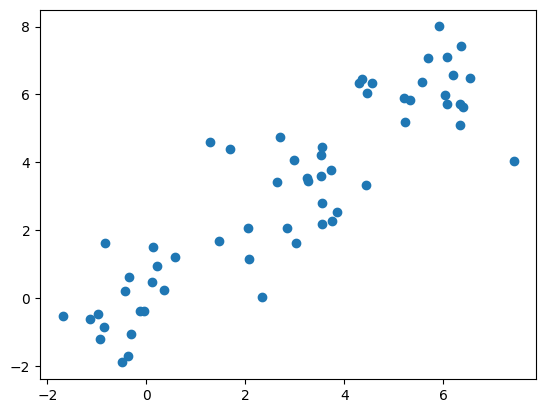

In [46]:
NUM_CLASSES = 3
NUM_OBS_PER_CLASS = 20
SHIFT = 3

# Generate simulated dataset
np.random.seed(420)

observations = []
for c in range(NUM_CLASSES):
    mean = np.zeros(50)
    mean += c * SHIFT
    x = np.random.normal(mean, 1, (20, 50))

    observations.append(x)

observations = np.concatenate(observations)

print(observations)
print(observations.shape)
plt.scatter(observations[:, :1], observations[:, 1:2])
plt.show()


 Perform PCA on the 60 observations and plot the first two prin-
cipal component score vectors. Use a different color to indicate
the observations in each of the three classes. If the three classes
appear separated in this plot, then continue on to part (c). If
not, then return to part (a) and modify the simulation so that
there is greater separation between the three classes. Do not
continue to part (c) until the three classes show at least some
separation in the first two principal component score vectors.

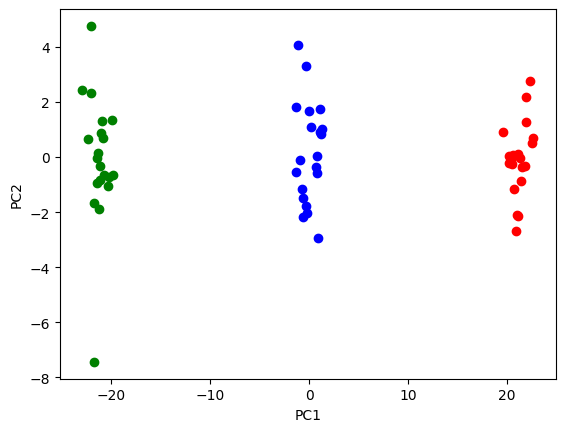

In [47]:
pca = PCA(n_components=2)
scores = pca.fit_transform(observations)

colors = ["green", "blue", "red"]

for c in range(NUM_CLASSES):
    plt.scatter(scores[(c * NUM_OBS_PER_CLASS):((c + 1) * NUM_OBS_PER_CLASS), 0], scores[(c * NUM_OBS_PER_CLASS):((c + 1) * NUM_OBS_PER_CLASS), 1], color=colors[c])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Perform K-means clustering of the observations with K = 3.
How well do the clusters that you obtained in K-means cluster-
ing compare to the true class labels?

Kmeans       0   1   2
True label            
0           20   0   0
1            0   0  20
2            0  20   0


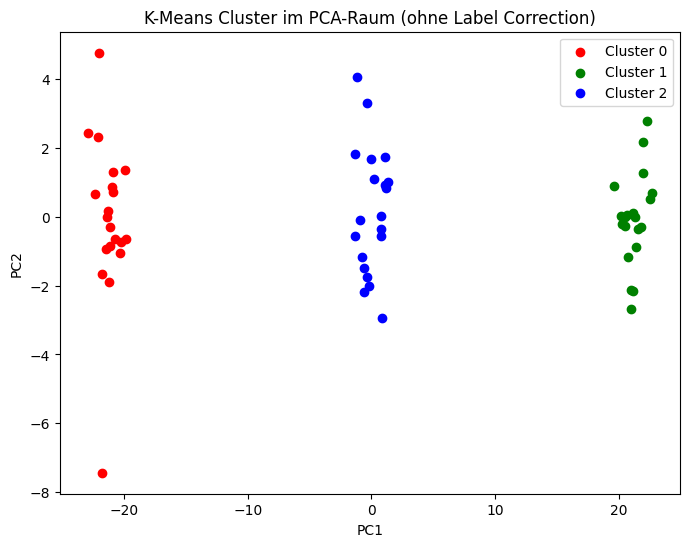

In [48]:
from sklearn.cluster import KMeans
import pandas as pd

true_labels = np.repeat(np.arange(NUM_CLASSES), NUM_OBS_PER_CLASS)

kmeans = KMeans(n_clusters=3, random_state=420)
labels = kmeans.fit_predict(observations)

comparison = pd.crosstab(true_labels, labels, rownames=["True label"], colnames=["Kmeans"])
print(comparison)

colors = ['red', 'green', 'blue']

plt.figure(figsize=(8,6))
for c in range(NUM_CLASSES):
    plt.scatter(scores[labels == c, 0],
                scores[labels == c, 1],
                color=colors[c],
                label=f'Cluster {c}')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Cluster im PCA-Raum (ohne Label Correction)")
plt.legend()
plt.show()

 Perform K-means clustering with K = 2. Describe your results.

Kmeans       0   1
True label        
0           20   0
1            0  20
2            0  20


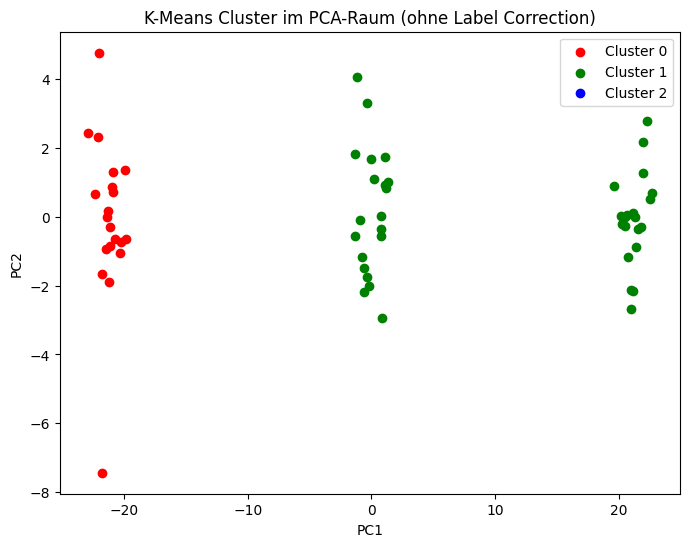

In [49]:
true_labels = np.repeat(np.arange(NUM_CLASSES), NUM_OBS_PER_CLASS)

kmeans = KMeans(n_clusters=2, random_state=420)
labels = kmeans.fit_predict(observations)

comparison = pd.crosstab(true_labels, labels, rownames=["True label"], colnames=["Kmeans"])
print(comparison)

colors = ['red', 'green', 'blue']

plt.figure(figsize=(8,6))
for c in range(NUM_CLASSES):
    plt.scatter(scores[labels == c, 0],
                scores[labels == c, 1],
                color=colors[c],
                label=f'Cluster {c}')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Cluster im PCA-Raum (ohne Label Correction)")
plt.legend()
plt.show()

Results: The cluster still get correctly identified, but it merges two clusters into one

Kmeans      0   1   2   3
True label               
0           5   0   0  15
1           0   0  20   0
2           0  20   0   0


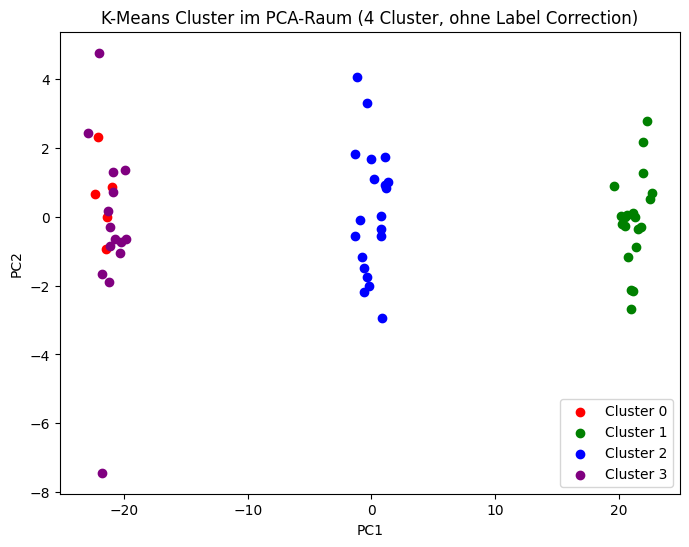

In [50]:
true_labels = np.repeat(np.arange(NUM_CLASSES), NUM_OBS_PER_CLASS)

kmeans = KMeans(n_clusters=4, random_state=420)
labels = kmeans.fit_predict(observations)

comparison = pd.crosstab(true_labels, labels, rownames=["True label"], colnames=["Kmeans"])
print(comparison)

colors = ['red', 'green', 'blue', 'purple']

plt.figure(figsize=(8,6))
for c in range(4):
    plt.scatter(scores[labels == c, 0],
                scores[labels == c, 1],
                color=colors[c],
                label=f'Cluster {c}')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Cluster im PCA-Raum (4 Cluster, ohne Label Correction)")
plt.legend()
plt.show()

Result: The first cluster is now split into two clusters

Using the StandardScaler() estimator, perform K-means clus-
tering with K = 3 on the data after scaling each variable to have
standard deviation one. How do these results compare to those
obtained in (b)? Explain.

Kmeans       0   1   2
True label            
0           20   0   0
1            0   0  20
2            0  20   0


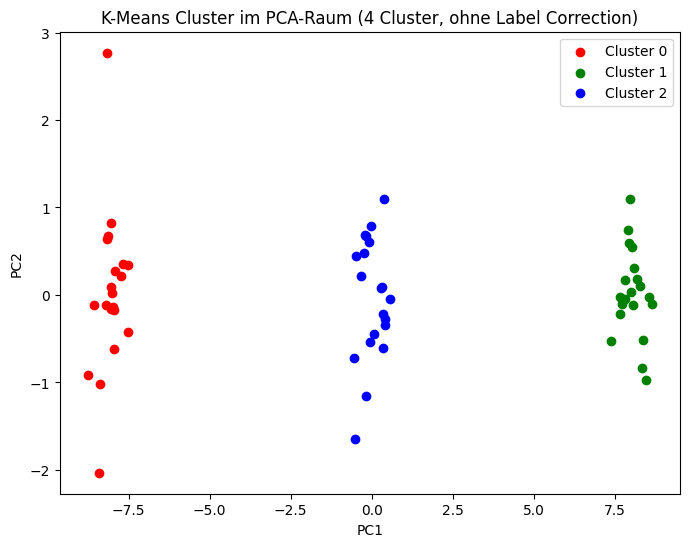

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
obs_scaled = scaler.fit_transform(observations)

pca_scaled = PCA(n_components=2)
scores_scaled = pca_scaled.fit_transform(obs_scaled)

true_labels = np.repeat(np.arange(NUM_CLASSES), NUM_OBS_PER_CLASS)

kmeans = KMeans(n_clusters=3, random_state=420)
labels = kmeans.fit_predict(obs_scaled)

comparison = pd.crosstab(true_labels, labels, rownames=["True label"], colnames=["Kmeans"])
print(comparison)

colors = ['red', 'green', 'blue', 'purple']

plt.figure(figsize=(8,6))
for c in range(NUM_CLASSES):
    plt.scatter(scores_scaled[labels == c, 0],
                scores_scaled[labels == c, 1],
                color=colors[c],
                label=f'Cluster {c}')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Cluster im PCA-Raum (4 Cluster, ohne Label Correction)")
plt.legend()
plt.show()

Results: The results are the same as in b).